# Lab 4 — Univariate & Bivariate Distributions

**Today you will:**
- Pull real air-quality data for Los Angeles from the EPA Air Quality System (AQS)
- Plot **univariate** distributions (histograms, density plots) and describe their shape
- **Transform** data with min-max normalization and z-scoring
- Explore a **bivariate** relationship between two pollutants (scatter plots, correlation)
- Build a simplified, data-driven **ozone isopleth** using real speciated VOC and NOx data
  from a Photochemical Assessment Monitoring Station (PAMS)


Most cells have blanks marked `____`. Fill them in based on the comments, the markdown above each cell, and what you know from lecture.


## 0 — Setup & Data Acquisition

We'll use the EPA's **Air Quality System (AQS)**, which publishes free, pre-packaged
daily-summary files for every pollutant, every year, at every monitoring site in the country:

```
https://aqs.epa.gov/aqsweb/airdata/daily_<parameter_code>_<year>.zip
```

Some AQS parameter codes you'll need today:

| Pollutant | AQS Parameter Code |
|---|---|
| Ozone (O₃) | `44201` |
| Nitrogen dioxide (NO₂) | `42602` |
| VOCS | We'll specifically look at isoprene, code `43243`|

We'll look at **Los Angeles – North Main Street**, a monitoring station in downtown LA
that has been operating since 1979 (AQS Site ID `06-037-1103`: state `06` = California,
county `037` = Los Angeles). It's also a long-standing **PAMS** (Photochemical Assessment
Monitoring Station) site, which is why it measures speciated VOCs in addition to the
usual criteria pollutants — that will matter in Section 4.

Import necessary libraries below.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (6, 4)

## Q1. Complete the function by including state and county codes in the body. Then load the 3 data frames by including the right parameter code.

In [2]:
def get_LA_csv(param_code, year):
    state_code="06" 
    county_code="037"
    site_num="1103"

    df = pd.read_csv(f'{data_path}daily_{param_code}_{year}.csv')

    #don't worry about anything below here.
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df["date_local"] = pd.to_datetime(df["date_local"])
    
    site_mask = (
        (df["state_code"].astype(str).str.zfill(2) == state_code)
        & (df["county_code"].astype(str).str.zfill(3) == county_code)
        & (df["site_num"].astype(str).str.zfill(4) == site_num)
    )

    # if param_code == 43243:
    #     site_df = df.loc[site_mask, ['parameter_name',"date_local", "arithmetic_mean", "1st_max_value", "units_of_measure"]]
    # else:
    site_df = df.loc[site_mask, ["date_local", "arithmetic_mean", "1st_max_value", "units_of_measure"]]
    site_df = site_df.sort_values("date_local").reset_index(drop=True)

    return site_df
    

In [3]:
year = 2023

# FILL IN HERE
ozone_code = 44201
no2_code = 42602
isop_code = 43243
data_path = 'epa_data/'

# Load Ozone (O3) with proper code variable defined just above.
o3_raw = get_LA_csv(ozone_code, year)

# # Load Nitrogen dioxide (NO2)
no2_raw = get_LA_csv(no2_code, year)

# # Load VOCs
voc_raw = get_LA_csv(isop_code, year) # no param code here.

print(f" Ozone (O3) units: {o3_raw['units_of_measure'].unique()[0]}\n", f"NO2 units: {no2_raw['units_of_measure'].unique()[0]}")
print(f"ISOP units: {voc_raw['units_of_measure'].unique()[0]}")

 Ozone (O3) units: Parts per million
 NO2 units: Parts per billion
ISOP units: Parts per billion Carbon


## Q2. Notice we have a **parts per million (ppm)** vs. **parts per billion (ppb)** mismatch between O3 and NO2/VOCs. Let's convert ozone to ppb below.

Hint/Recall: 1 ppm = 1000 ppb.


In [4]:
o3_raw

,date_local,arithmetic_mean,1st_max_value,units_of_measure
0,2023-01-01,0.028412,0.035,Parts per million
1,2023-01-02,0.019353,0.027,Parts per million
2,2023-01-03,0.019235,0.029,Parts per million
3,2023-01-04,0.027588,0.032,Parts per million
4,2023-01-05,0.019176,0.038,Parts per million
...,...,...,...,...
360,2023-12-27,0.012412,0.022,Parts per million
361,2023-12-28,0.014176,0.030,Parts per million
362,2023-12-29,0.023083,0.026,Parts per million
363,2023-12-30,0.016471,0.036,Parts per million


In [5]:
o3 = o3_raw.rename(columns={"arithmetic_mean": "o3_ppb", '1st_max_value': "o3_max_ppb"})[['date_local', "o3_ppb", "o3_max_ppb"]]
o3["o3_ppb"] = o3["o3_ppb"] * 1000      # convert ppm -> ppb
o3["o3_max_ppb"] = o3["o3_max_ppb"] * 1000

no2 = no2_raw.rename(columns={"arithmetic_mean": 'no2_ppb', "1st_max_value": "no2_max_ppb"})[['date_local', "no2_ppb", "no2_max_ppb"]]
voc = voc_raw.rename(columns={"arithmetic_mean": 'voc_ppb', "1st_max_value": "voc_max_ppb"})[['date_local', "voc_ppb", "voc_max_ppb"]]

o3.head() # much nicer

,date_local,o3_ppb,o3_max_ppb
0,2023-01-01,28.412,35.0
1,2023-01-02,19.353,27.0
2,2023-01-03,19.235,29.0
3,2023-01-04,27.588,32.0
4,2023-01-05,19.176,38.0


In [6]:
voc


,date_local,voc_ppb,voc_max_ppb
0,2023-01-06,0.23,0.23
1,2023-01-12,0.33,0.33
2,2023-01-18,0.21,0.21
3,2023-01-24,0.28,0.28
4,2023-01-30,0.07,0.07
...,...,...,...
197,2023-12-08,0.36,0.36
198,2023-12-12,0.62,0.62
199,2023-12-14,0.63,0.63
200,2023-12-20,0.15,0.15


Let's merge ozone and NO₂ into a single dataframe **on date**. This keeps only measurement days where both NO2 and O3 exist.

HINT: this will help you on your homework.

In [7]:
df_no2_o3 = o3.merge(no2, how='inner', on='date_local') # which two dfs are we merging??

print(f"o3 alone: {len(o3)} days | no2 alone: {len(no2)} days | merged: {len(df_no2_o3)} days")
df_no2_o3.head()

o3 alone: 365 days | no2 alone: 730 days | merged: 730 days


,date_local,o3_ppb,o3_max_ppb,no2_ppb,no2_max_ppb
0,2023-01-01,28.412,35.0,4.550000,18.7
1,2023-01-01,28.412,35.0,4.816667,17.5
2,2023-01-02,19.353,27.0,14.720833,21.6
3,2023-01-02,19.353,27.0,15.416667,22.2
4,2023-01-03,19.235,29.0,11.608333,21.5


To make life easier, and to deduplicate dates, let's average no2 values within each day. Don't worry about the code here, just run.


In [8]:
df_no2_o3 = df_no2_o3.groupby('date_local', as_index=False).mean(numeric_only=True)
df_no2_o3.head() # no more duplicated dates.

,date_local,o3_ppb,o3_max_ppb,no2_ppb,no2_max_ppb
0,2023-01-01,28.412,35.0,4.683333,18.10
1,2023-01-02,19.353,27.0,15.068750,21.90
2,2023-01-03,19.235,29.0,11.662500,21.15
3,2023-01-04,27.588,32.0,14.363637,24.80
4,2023-01-05,19.176,38.0,11.027083,26.55


## Q3. Double merge alert: let's merge **again** on the voc data frame, again on **date**

In [9]:
df_3 = df_no2_o3.merge(voc, on='date_local') # which extra df are we merging with?
df_3.head()
print(df_3.shape[0], 'days overlap')

202 days overlap


## 1 — Univariate Distributions

Let's look at our daily VOC distribution on their own, since you'll look at O3 and NO2 in your homework. Please use the `voc` dataframe here.

## Q. Fill in the blanks below 


In [10]:
voc

,date_local,voc_ppb,voc_max_ppb
0,2023-01-06,0.23,0.23
1,2023-01-12,0.33,0.33
2,2023-01-18,0.21,0.21
3,2023-01-24,0.28,0.28
4,2023-01-30,0.07,0.07
...,...,...,...
197,2023-12-08,0.36,0.36
198,2023-12-12,0.62,0.62
199,2023-12-14,0.63,0.63
200,2023-12-20,0.15,0.15


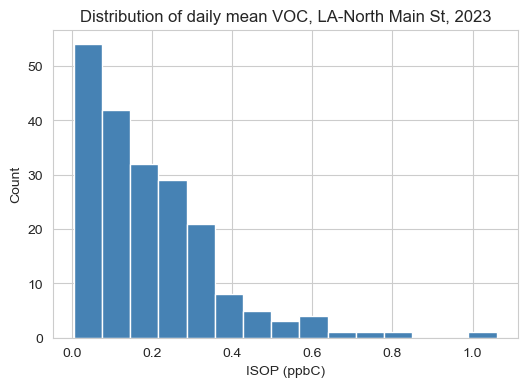

In [11]:
fig, ax = plt.subplots()
ax.hist(voc["voc_ppb"], bins=15, color="steelblue", edgecolor="white")
ax.set_xlabel("ISOP (ppbC)")
ax.set_ylabel("Count")
ax.set_title("Distribution of daily mean VOC, LA-North Main St, " + str(year))
plt.show()

Now a **density plot** (a smoothed version of a histogram) for VOC. Seaborn's
`kdeplot` estimates the probability *density* rather than counting into bins.


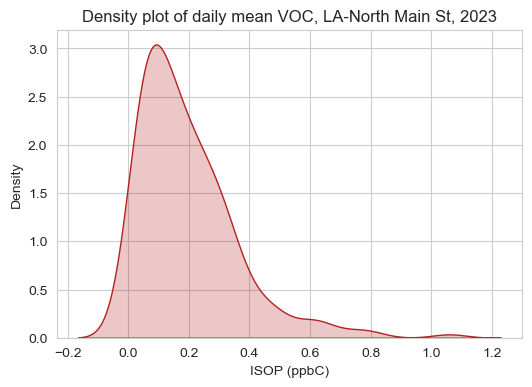

In [12]:
fig, ax = plt.subplots()
sns.kdeplot(voc['voc_ppb'], fill=True, color="firebrick", ax=ax)
ax.set_xlabel("ISOP (ppbC)")
ax.set_title("Density plot of daily mean VOC, LA-North Main St, " + str(year))
plt.show()

**Describe the shape.** Fill in the summary statistics below, then answer in the
markdown cell that follows: is VOC symmetric, or skewed? What about NO₂?

**VOC is not symmetric and slightly skewed left but not heavily. As for NO2, that plot is distributed more widely than VOC as it does not have that tail that VOC has between 0.8-1.2 ppbC. However, NO2 has one large peak, then a smaller, flatter peak where NO2 is 10ppb and 30ppb respectively.**

## Q. Find which functions to find the mean, median, and standard devation.


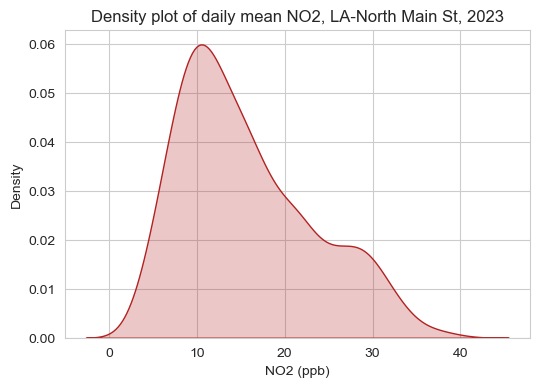

In [13]:
fig, ax = plt.subplots()
sns.kdeplot(no2['no2_ppb'], fill=True, color="firebrick", ax=ax)
ax.set_xlabel("NO2 (ppb)")
ax.set_title("Density plot of daily mean NO2, LA-North Main St, " + str(year))
plt.show()

In [14]:
no2

,date_local,no2_ppb,no2_max_ppb
0,2023-01-01,4.550000,18.7
1,2023-01-01,4.816667,17.5
2,2023-01-02,14.720833,21.6
3,2023-01-02,15.416667,22.2
4,2023-01-03,11.608333,21.5
...,...,...,...
725,2023-12-29,22.957895,32.1
726,2023-12-30,13.291667,25.2
727,2023-12-30,14.025000,26.0
728,2023-12-31,15.858333,28.8


In [15]:
df_3

,date_local,o3_ppb,o3_max_ppb,no2_ppb,no2_max_ppb,voc_ppb,voc_max_ppb
0,2023-01-06,12.412,26.0,21.725000,32.30,0.23,0.23
1,2023-01-12,9.235,20.0,24.610417,35.95,0.33,0.33
2,2023-01-18,15.471,31.0,21.283333,30.55,0.21,0.21
3,2023-01-24,12.882,27.0,29.427084,38.05,0.28,0.28
4,2023-01-30,15.824,31.0,14.814583,33.75,0.07,0.07
...,...,...,...,...,...,...,...
197,2023-12-08,15.647,34.0,22.295834,38.25,0.36,0.36
198,2023-12-12,12.647,29.0,32.952084,42.70,0.62,0.62
199,2023-12-14,12.765,30.0,28.568750,44.00,0.63,0.63
200,2023-12-20,18.294,22.0,15.506250,22.55,0.15,0.15


In [16]:
for col, name in [("o3_ppb", "O3"), ("no2_ppb", "NO2"), ("voc_ppb", "VOC")]:
    mean_ = df_3[col].mean()
    median_ = df_3[col].median()
    std_ = df_3[col].std()
    skew_ = stats.skew(df_3[col])
    print(f"{name}: mean={mean_:.1f}, median={median_:.1f}, std={std_:.1f}, skew={skew_:.2f}")

O3: mean=30.8, median=31.8, std=7.3, skew=-0.55
NO2: mean=12.6, median=11.3, std=5.8, skew=1.11
VOC: mean=0.2, median=0.2, std=0.2, skew=1.79


## Section 2 — Transforming Data

Sometimes when two variables are on very different scales, we need to transform them
to values sharing a common range. This is **extremely useful for those pursuing a ML project.**

Two of the most common transforms:

- **Min-max normalization** squeezes a variable into the range [0, 1]:
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- **Z-scoring (standardization)** centers a variable at 0 with a standard deviation of 1:
$$z = \frac{x - \bar{x}}{s}$$

Fill in the two functions below using the formulas above.


In [17]:
def min_max_normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

def z_score(x):
    return (x - np.mean(x)) / np.std(x)


df_3["voc_minmax"] = min_max_normalize(df_3['voc_ppb'])
df_3["voc_z"] = z_score(df_3['voc_ppb'])

print('min-max results:', df_3["voc_minmax"].min(), df_3["voc_minmax"].max())
print('z-score results:', df_3["voc_z"].mean(), df_3["voc_z"].std())

min-max results: 0.0 1.0
z-score results: 3.51753829584208e-17 1.002484475878858


Let's visualize all three versions of the VOC distribution side by side. Notice
what stays the same and what changes.


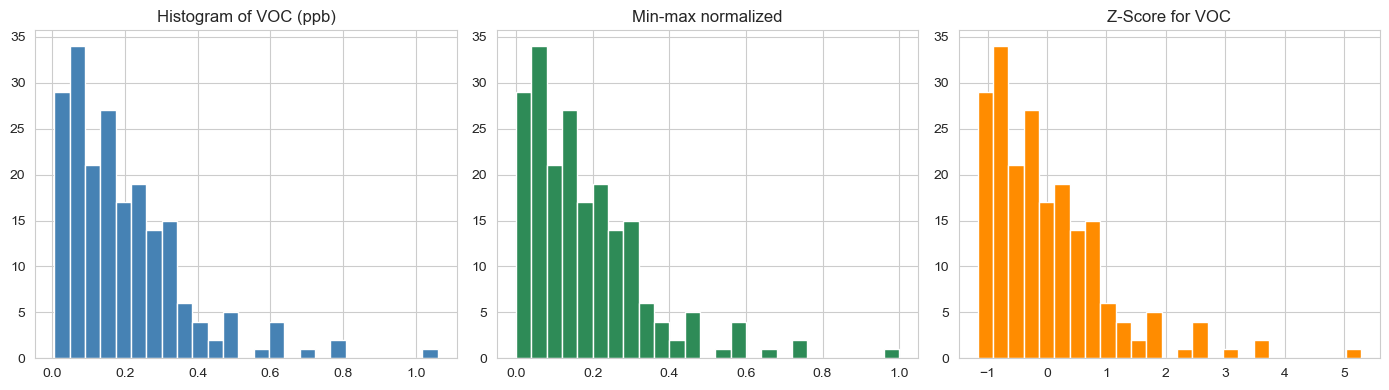

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_3["voc_ppb"], bins=25, color="steelblue")
axes[0].set_title("Histogram of VOC (ppb)")

axes[1].hist(df_3['voc_minmax'], bins=25, color="seagreen")
axes[1].set_title("Min-max normalized")

axes[2].hist(df_3['voc_z'], bins=25, color="darkorange")
axes[2].set_title("Z-Score for VOC")

plt.tight_layout()
plt.show()

✏️ **Quick check (1 sentence):** What changed, and what stayed the same? Pay attention to distribution shape and x-axis labels. 

**The distribution and range of the data (y-axis) is the same, however, the range of the x axis changed when it came to the Z-score**


## Section 3 — Bivariate Relationships

A **bivariate distribution** describes how two variables vary *together*. Let's look
at **VOC** vs. **NO₂** on the same day. 

## **Please use `df_3` here.**


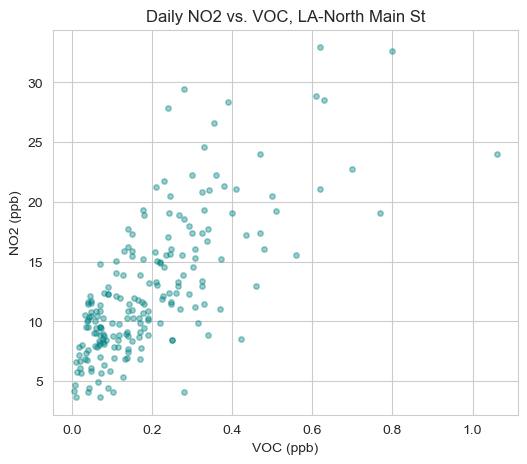

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_3['voc_ppb'], df_3['no2_ppb'], alpha=0.4, s=15, color="teal")
ax.set_xlabel("VOC (ppb)")
ax.set_ylabel("NO2 (ppb)")
ax.set_title("Daily NO2 vs. VOC, LA-North Main St")
plt.show()

## Q4: Determine the linear correlation between these two variables. This will give a sense of how connected these are.

In [20]:
r, p = stats.pearsonr(df_3['voc_ppb'], df_3['no2_ppb'])
print(f"Pearson correlation r = {r:.2f}  (p = {p:.2e})")

Pearson correlation r = 0.73  (p = 1.74e-34)


✏️ **Quick check (2 sentences):** What **type** of correlation is this? Look at the **sign** of the r value here. Briefly describe what this reflects in the plot of data.

**This shows a strong correlation becatse the r value is positive with it being relatively close to a value of 1. As for the p value, the value is small, meaning it's highly significant.**

## Q5. Plot a **joint density** plot of VOC vs NO2 values.

This shows where observations *cluster* — useful when you have a lot of overlapping points. 


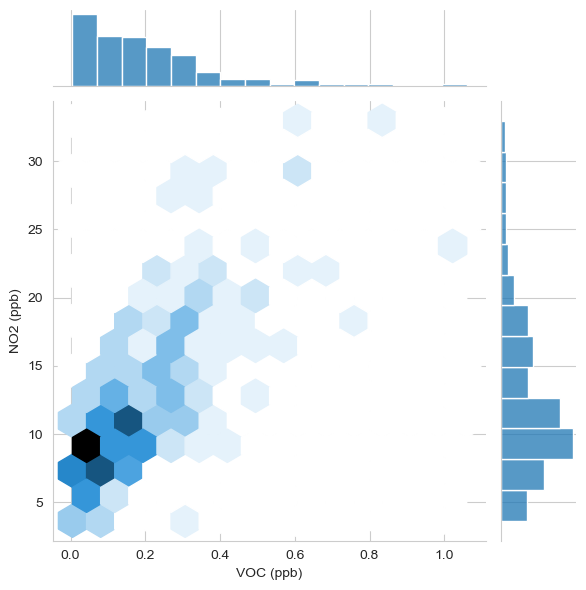

In [21]:
ax=sns.jointplot(data=df_3, x="voc_ppb", y="no2_ppb", kind='hex', height=6)
ax.set_axis_labels('VOC (ppb)', 'NO2 (ppb)')
plt.show()

## Q5. using the same joint plot function, plot a different combination of variables in `df_3` using `jointplot()`

In [22]:
df_3

,date_local,o3_ppb,o3_max_ppb,no2_ppb,no2_max_ppb,voc_ppb,voc_max_ppb,voc_minmax,voc_z
0,2023-01-06,12.412,26.0,21.725000,32.30,0.23,0.23,0.213093,0.208411
1,2023-01-12,9.235,20.0,24.610417,35.95,0.33,0.33,0.307901,0.820048
2,2023-01-18,15.471,31.0,21.283333,30.55,0.21,0.21,0.194131,0.086084
3,2023-01-24,12.882,27.0,29.427084,38.05,0.28,0.28,0.260497,0.514230
4,2023-01-30,15.824,31.0,14.814583,33.75,0.07,0.07,0.061400,-0.770207
...,...,...,...,...,...,...,...,...,...
197,2023-12-08,15.647,34.0,22.295834,38.25,0.36,0.36,0.336343,1.003539
198,2023-12-12,12.647,29.0,32.952084,42.70,0.62,0.62,0.582844,2.593793
199,2023-12-14,12.765,30.0,28.568750,44.00,0.63,0.63,0.592325,2.654956
200,2023-12-20,18.294,22.0,15.506250,22.55,0.15,0.15,0.137246,-0.280898


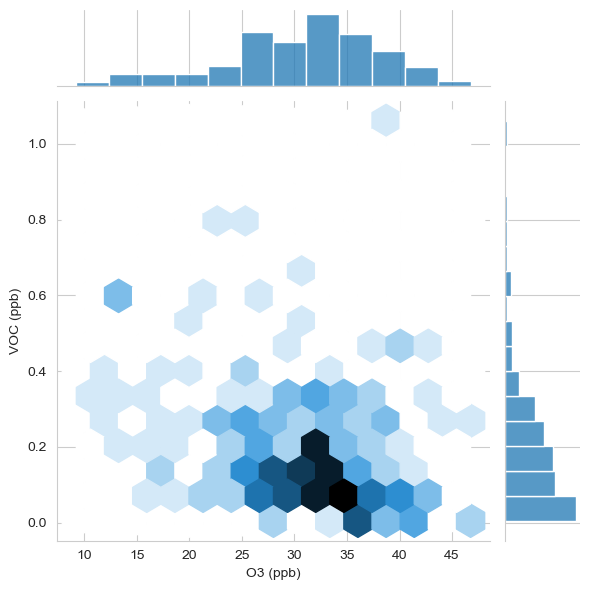

In [23]:
# your answer here.
ax=sns.jointplot(data=df_3, x="o3_ppb", y="voc_ppb", kind='hex', height=6)
ax.set_axis_labels('O3 (ppb)', 'VOC (ppb)')
plt.show()

## Section 4 — Examining the relationship between Ozone and its precursors.

It is known that VOCs like isoprene and NO2 produce ozone secondarily in the atmosphere. It is often useful to visualize the relationship of these 3 variables. Unlike above, where we **just** looked at NO2 and VOC relationships, we want to see how ozone responds as a sort of "function" of the two precursors. This is what is known as the ozone **isopleth** 


In [24]:
## Last Q. Fill in the proper variables below to visualize the ozone response to VOCs and NO2.

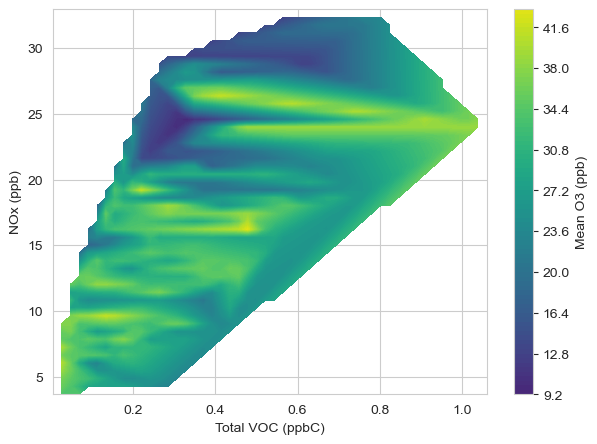

In [25]:
from scipy.interpolate import griddata


x = df_3["voc_ppb"].values # voc
y = df_3["no2_ppb"].values # NO2
z = df_3["o3_ppb"].values # O3

# 1. build a regular grid spanning the data's range
n_grid = 50  # resolution of the output grid (not the number of data points)
xi = np.linspace(x.min(), x.max(), n_grid)
yi = np.linspace(y.min(), y.max(), n_grid)
Xi, Yi = np.meshgrid(xi, yi)   # both shape (n_grid, n_grid)

# 2. interpolate z from the scattered (x, y) points onto that grid
Zi = griddata(
    points=(x, y),      # your original scattered coordinates
    values=z,           # your original scattered response values
    xi=(Xi, Yi),        # where you want values estimated
    method="linear",    # "nearest" and "cubic" are the other options
)

# 3. plot
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xi, Yi, Zi, levels=100, cmap="viridis", vmin=5, vmax=45)
fig.colorbar(cf, ax=ax, label="Mean O3 (ppb)")
ax.set_xlabel("Total VOC (ppbC)")
ax.set_ylabel("NOx (ppb)")
plt.show()


Admittedly, this is a pretty rough figure. [This](https://www.researchgate.net/publication/321780837/figure/fig3/AS:960013174595603@1605896385484/Calculated-ozone-isopleths-for-the-base-case-scenario-Also-shown-are-isoprene.gif) is what the typical version of the ozone isopleth looks like. There are many reasons for our different plot here.

The point here is that you may find it useful to plot a 3-D function as a response to two variables in the future. This is very important if you aim to plot spatial data in the future. 

## Lab submission and Final Questions
Save your notebook and make sure it runs top-to-bottom before submitting (`Kernel →
Restart & Run All`). 

### Mini evaluations

1. Please rank from 1-5 how approachable this lab was for you. 5 = too easy, why did we even do this? 1 = too difficult, I felt very lost trying to complete this. 
**3.5**

2. Please write an additional 1-3 sentences explaining what did/not work well for you. 
**I thought that the lab was approachable and liked the questions since it helped me better understand the data I am working with. Would it be possible to have the questions listed seperately? When they are distributed throughout the code, I sometimes miss it since it's kind of chunked in between code and descriptions/instructions**